## 1. Imports

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import catppuccin
import shap

import joblib
from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)

## 2. Load data and model

In [31]:
DF_PATH = Path("../data/processed/hour_feature_engineered.parquet")
df = pd.read_parquet(DF_PATH)

MODEL_PATH = Path("../models/xg_boost_tuned.pkl")
model = joblib.load(MODEL_PATH)

MODEL_CV_RESULTS_PATH = Path("../data/processed/best_model_cv_results.csv")
model_cv_results_df = pd.read_csv(MODEL_CV_RESULTS_PATH)

MODEL_METRICS_PATH = Path("../data/processed/best_model_metrics_df.csv")
model_metrics_df = pd.read_csv(MODEL_METRICS_PATH)

CLASSICAL_FOREC_MODELS_METRICS_PATH = Path("../data/processed/classical_forecasting_models_metrics.csv")
classical_forec_models_metrics_df = pd.read_csv(CLASSICAL_FOREC_MODELS_METRICS_PATH, index_col=0)

CLASSICAL_FOREC_MODELS_PREDICTIONS_PATH = Path("../data/processed/classical_forecasting_models_predictions.csv")
classical_forec_models_pred_df = pd.read_csv(CLASSICAL_FOREC_MODELS_PREDICTIONS_PATH)

OPTUNA_OPT_XG_BOOST_METRICS_PATH = Path("../data/processed/optuna_optimized_xg_boost_metrics.csv")
optuna_opt_xgb_metrics_df = pd.read_csv(OPTUNA_OPT_XG_BOOST_METRICS_PATH, index_col=0)

OPTUNA_TRIALS_PATH = Path("../data/processed/optuna_trials.csv")
optuna_trials_df = pd.read_csv(OPTUNA_TRIALS_PATH)

## 3. Recreate the train and test splits

In [32]:
train = df[(df["dteday"] >= pd.Timestamp(2011, 1, 8)) & (df["dteday"] <= pd.Timestamp(2012, 9, 30))]
valid = df[df["dteday"] > pd.Timestamp(2012, 9, 30)]

X_train = train.drop(columns=["dteday", "cnt"])
y_train = train["cnt"]
X_test = valid.drop(columns=["dteday", "cnt"])
y_test = valid["cnt"]

## 4. Predictions and metrics

In [33]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_results = pd.DataFrame({
    "R² score": r2_score(y_train, train_pred),
    "MAE": mean_absolute_error(y_train, train_pred),
    "RMSE": root_mean_squared_error(y_train, train_pred),
}, index=["Training Set"])

test_results = pd.DataFrame({
    "R² score": r2_score(y_test, test_pred),
    "MAE": mean_absolute_error(y_test, test_pred),
    "RMSE": root_mean_squared_error(y_test, test_pred),
}, index=["Test Set"])

# look at the training set results
train_results.head()

,R² score,MAE,RMSE
Training Set,0.97403,19.295588,28.732891


In [34]:
# look at the test set results
test_results.head()

,R² score,MAE,RMSE
Test Set,0.948105,29.082729,45.922104


# 5. Overfitting analysis

Tuned XG Boost achieved great performance in both the training and test sets as evidenced by the high R² score. This also means that the model doesn't underfit the data and learns general patterns pretty well.

However, both MAE and RMSE scores are higher in the test set indicating that the model predicted better, on average, during the training phase.

## 6. Actual vs. Predicted Plot

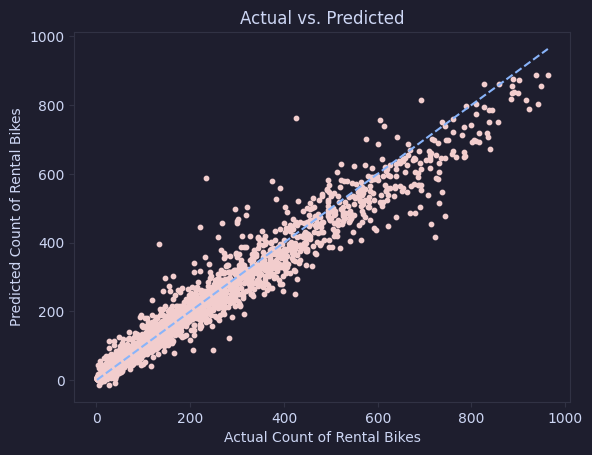

In [35]:
plt.style.use("mocha")
plt.scatter(y_test, test_pred, color=catppuccin.PALETTE.mocha.colors.flamingo.hex, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color=catppuccin.PALETTE.mocha.colors.blue.hex, linestyle="--")
plt.title("Actual vs. Predicted")
plt.xlabel("Actual Count of Rental Bikes")
plt.ylabel("Predicted Count of Rental Bikes")
plt.show()

The points cluster closely on the diagonal line, which indicates that the model did a great job in predicting the target feature. The plot doesn't show residual patterns which would indicate model's struggle in making predictions.

## 7. Residuals Histogram

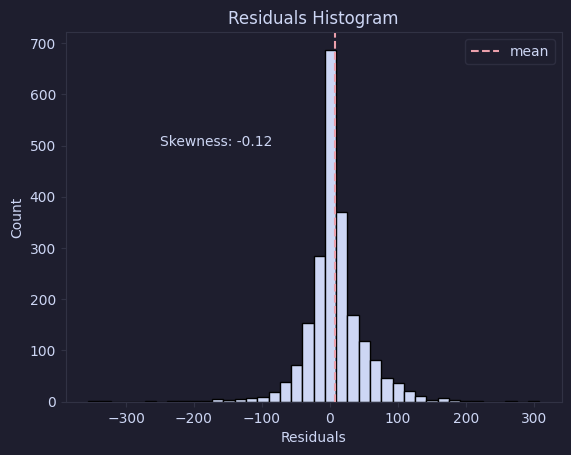

In [36]:
residuals = y_test - test_pred

plt.hist(residuals, color=catppuccin.PALETTE.mocha.colors.text.hex, edgecolor="black", bins=40)
plt.axvline(x=np.array(residuals).mean(), color=catppuccin.PALETTE.mocha.colors.maroon.hex, linestyle="--", label="mean")
plt.title("Residuals Histogram")
plt.text(x=-250, y=500, s=f"Skewness: {residuals.skew():.2f}")
plt.xlabel("Residuals")
plt.ylabel("Count")
plt.legend()
plt.show()

Residuals are centered near zero and approximately symmetric, suggesting that the model doesn't systematically over- or under-predict demand.

## 8. Residuals Scatter Plot

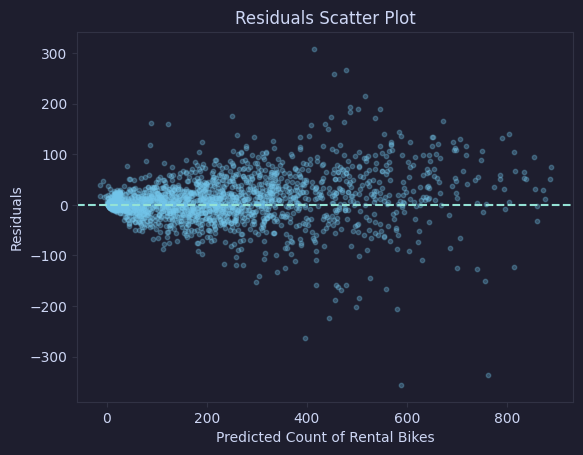

In [37]:
plt.scatter(test_pred, residuals, color=catppuccin.PALETTE.mocha.colors.sapphire.hex, s=10, alpha=0.3)
plt.axhline(y=0, linestyle="--", color=catppuccin.PALETTE.mocha.colors.teal.hex)
plt.xlabel("Predicted Count of Rental Bikes")
plt.ylabel("Residuals")
plt.title("Residuals Scatter Plot")
plt.show()

The residuals tend to be closer to 0 on the left side of the plot but, as target values increase, the residuals also get more dispersed. The increasing spread of residuals for larger predicted counts suggests that prediction uncertainty grows as demand increases. Consequently, larger errors contribute more strongly to the RMSE than to the MAE.

## 9. Feature Importance

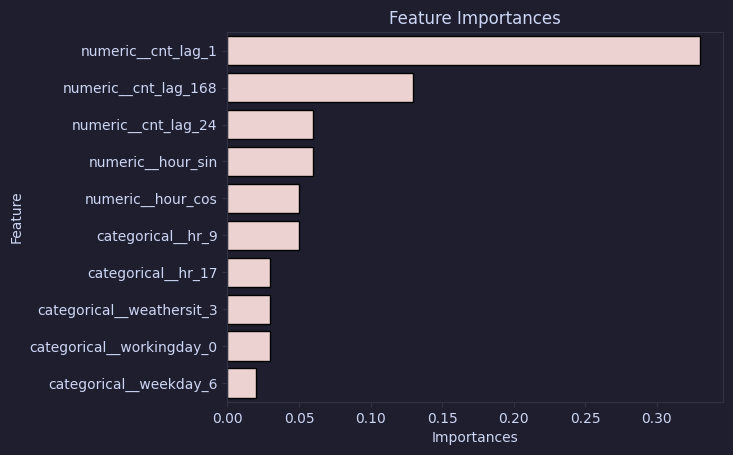

In [38]:
preprocessor = model.named_steps["preprocessor"]
xg_boost_model = model.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()

importances_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": xg_boost_model.feature_importances_,
    }
).round(2).sort_values(by="importance", ascending=False)

top_ten_importances_df = importances_df.nlargest(n=10, columns="importance")

# plot feature importances
sns.barplot(data=top_ten_importances_df, x="importance", y="feature", orient="h", color=catppuccin.PALETTE.mocha.colors.flamingo.hex, edgecolor="black")
plt.xlabel("Importances")
plt.ylabel("Feature")
plt.title("Feature Importances")
plt.show()

The top ten feature importance plot demonstrates that engineered features became some of the most influential predictors, with the top 5 features being: `cnt_lag_1` (0.33), `cnt_lag_168` (0.13), `cnt_lag_24` (0.06), `hour_sin` (0.06) and `hour_cos` (0.05). In particular, these five alone accounted for 0.63 out of 1.

## 10. Model Metrics

In [39]:
model_metrics_df.head()

,Model Name,CV Mean R² score,CV Std,Test R² score,MAE,RMSE
0,XG Boost Tuned,0.91,0.02,0.95,29.08,45.92


XG Boost Tuned performed slightly better compared to the baseline model:

- the baseline model achieved a 0.90 CV Mean R² score compared to 0.91 of the tuned model. 
- the tuned model's MAE slightly decreased to 29.08 (from 31.50), indicating that predictions are off, on average, by about 29.08.
- the RMSE slighly decreased but not meaningfully: from 50.81 to 45.92.

This suggests that the baseline model already is a strong starting point for modeling and hyperparameter tuning doesn't affect performance substantially.

## 11. CV Results

In [40]:
model_cv_results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__learning_rate,param_model__max_depth,param_model__n_estimators,param_model__subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.092133,0.034198,0.010385,0.000734,0.01,3,100,0.5,"{'model__learning_rate': 0.01, 'model__max_dep...",0.506622,0.673854,0.671082,0.529637,0.615709,0.599381,0.069889,35
1,0.066593,0.009380,0.010511,0.000621,0.01,3,100,1.0,"{'model__learning_rate': 0.01, 'model__max_dep...",0.507076,0.678415,0.671419,0.522322,0.615124,0.598871,0.072306,36
2,0.120094,0.015993,0.010288,0.000967,0.01,3,200,0.5,"{'model__learning_rate': 0.01, 'model__max_dep...",0.752202,0.813333,0.799092,0.721868,0.807671,0.778833,0.035739,29
3,0.127040,0.031198,0.011614,0.002475,0.01,3,200,1.0,"{'model__learning_rate': 0.01, 'model__max_dep...",0.737891,0.816916,0.805779,0.711360,0.802592,0.774908,0.042173,30
4,0.144359,0.005726,0.012672,0.002008,0.01,5,100,0.5,"{'model__learning_rate': 0.01, 'model__max_dep...",0.555478,0.736059,0.730767,0.568948,0.684122,0.655075,0.078063,34


In [41]:
# best parameters based on the test score
best = model_cv_results_df.sort_values(by="mean_test_score", ascending=False).head(10)

best[["param_model__learning_rate", "param_model__max_depth", "param_model__n_estimators", "param_model__subsample"]]

,param_model__learning_rate,param_model__max_depth,param_model__n_estimators,param_model__subsample
18,0.05,5,200,0.5
26,0.10,3,200,0.5
27,0.10,3,200,1.0
29,0.10,5,100,1.0
19,0.05,5,200,1.0
30,0.10,5,200,0.5
31,0.10,5,200,1.0
28,0.10,5,100,0.5
22,0.05,7,200,0.5
16,0.05,5,100,0.5


In [42]:
# best parameters
best_model = model_cv_results_df.sort_values(by="rank_test_score").iloc[0]
best_model[["params", "mean_test_score", "std_test_score", "rank_test_score"]]

params             {'model__learning_rate': 0.05, 'model__max_dep...
mean_test_score                                             0.913533
std_test_score                                              0.023723
rank_test_score                                                    1
Name: 18, dtype: object

## 12. Error Analysis

In [43]:
results_df = X_test.copy()
results_df["actual"] = y_test
results_df["predicted"] = test_pred
results_df["error"] = abs(y_test - test_pred)

# largest errors
results_df.sort_values(by="error", ascending=False).head(10)

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,hour_sin,hour_cos,month_sin,month_cos,cnt_lag_1,cnt_lag_24,cnt_lag_168,actual,predicted,error
15493,4,1,10,18,0,5,1,1,0.56,0.5303,...,-1.000000,-1.836970e-16,-8.660254e-01,0.500000,425.0,788.0,642.0,233,588.633789,355.633789
15492,4,1,10,17,0,5,1,3,0.62,0.6061,...,-0.965926,-2.588190e-01,-8.660254e-01,0.500000,565.0,890.0,837.0,425,761.911682,336.911682
15744,4,1,10,17,0,3,1,2,0.40,0.4091,...,-0.965926,-2.588190e-01,-8.660254e-01,0.500000,424.0,124.0,50.0,723,415.134857,307.865143
15302,4,1,10,19,0,4,1,1,0.44,0.4394,...,-0.965926,2.588190e-01,-8.660254e-01,0.500000,692.0,566.0,534.0,743,477.729126,265.270874
15075,4,1,10,8,0,2,1,3,0.60,0.5455,...,0.866025,-5.000000e-01,-8.660254e-01,0.500000,260.0,784.0,805.0,134,396.834656,262.834656
15243,4,1,10,8,0,2,1,2,0.42,0.4242,...,0.866025,-5.000000e-01,-8.660254e-01,0.500000,362.0,397.0,134.0,713,453.794098,259.205902
15795,4,1,11,20,0,5,1,2,0.36,0.3333,...,-0.866025,5.000000e-01,-5.000000e-01,0.866025,374.0,296.0,779.0,221,445.345673,224.345673
16525,4,1,12,8,0,1,1,1,0.36,0.3788,...,0.866025,-5.000000e-01,-2.449294e-16,1.000000,396.0,93.0,365.0,731,515.742493,215.257507
16247,4,1,11,17,0,3,1,1,0.40,0.4091,...,-0.965926,-2.588190e-01,-5.000000e-01,0.866025,469.0,590.0,583.0,374,580.431763,206.431763
15771,4,1,11,20,0,4,1,2,0.38,0.3939,...,-0.866025,5.000000e-01,-5.000000e-01,0.866025,452.0,268.0,801.0,296,498.036163,202.036163


In [44]:
# are errors larger in certain seasons?
results_df.groupby("season")["error"].mean()

season
1    17.399568
4    30.688702
Name: error, dtype: float64

In [45]:
# are errors larger in certain months?
results_df.groupby("mnth")["error"].mean()

mnth
10    36.307831
11    29.328200
12    21.951160
Name: error, dtype: float64

According to the data, prediction errors tend be larger in winter (30.7) compared to spring (17.4). Furthermore, errors decrease as the year ends, going from 36.3 in October to 29.3 in November and 22 in December.

## 13. SHAP values

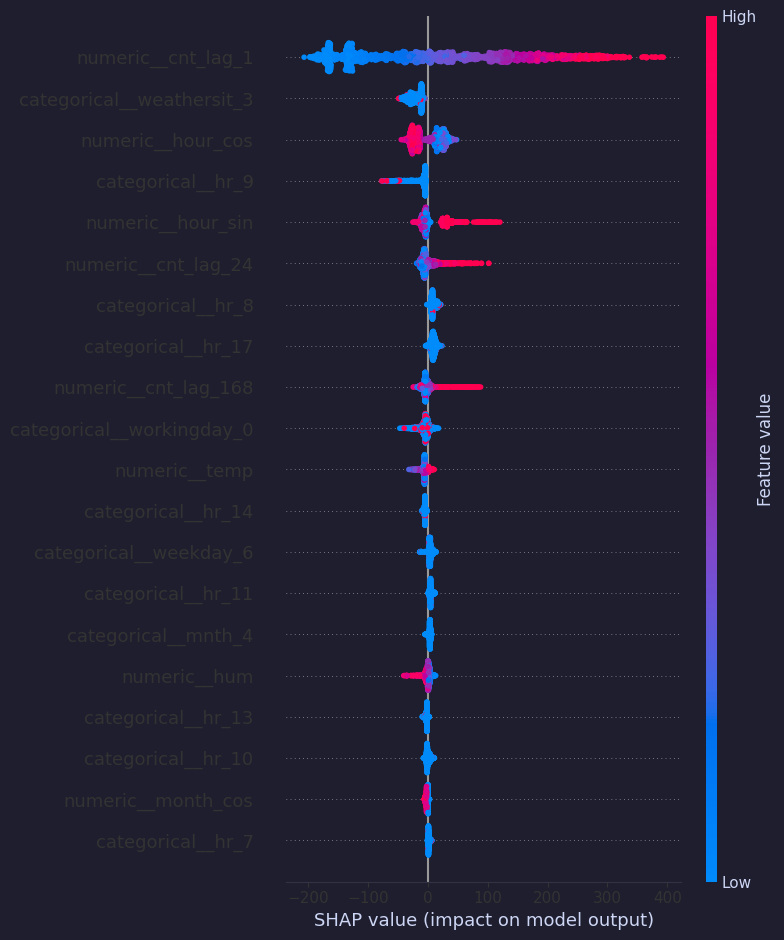

In [46]:
# transform the data
X_test_processed = preprocessor.transform(X_test).toarray()
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)

# create explainer
explainer = shap.TreeExplainer(xg_boost_model)

# compute SHAP values
shap_values = explainer.shap_values(X_test_processed)

# global importance
shap.summary_plot(shap_values, X_test_processed_df, show=False)

SHAP analysis showed that lagged demand variables were the most influential predictors of bike rentals, particularly the counts from the previous hour (`cnt_lag_1`), previous day (`cnt_lag_24`), and previous week (`cnt_lag_168`). Higher values of these lag features generally increased predicted demand, while lower values reduced it.

Temporal effects were also important. The cyclical hour features (`hour_sin`, `hour_cos`) and selected hour indicators contributed to predictions, with observations outside the 9 AM commuting period tending to reduce predicted demand and the 5 PM hour showing a smaller positive effect.

Weather conditions also influenced demand: severe weather (`weathersit_3` = 1) consistently pushed predictions downward, indicating lower expected bike rental activity during poor weather conditions.

## 14. ARIMA and SARIMA metrics

In [47]:
classical_forec_models_metrics_df.head()

,R² score,MAE,RMSE
ARIMA,-0.58,178.85,253.12
SARIMA,-1.34,243.25,308.68


Both ARIMA and SARIMA substantially underperformed tuned XG Boost which could exploit additional explanatory variables such as weather conditions, calendar features and engineered lag features. 
These additional predictors allow the gradient boosting model to capture more complex relationships in bike rental demand.

In this implementation, ARIMA and SARIMA relied solely on historical demand values.

## 15. ARIMA and SARIMA predictions

In [48]:
classical_forec_models_pred_df.head()

,actual,ARIMA predictions,SARIMA predictions
0,45,54.332141,46.927981
1,18,63.890584,49.462587
2,12,69.043123,52.359609
3,7,68.119624,37.249864
4,10,66.035239,13.610513


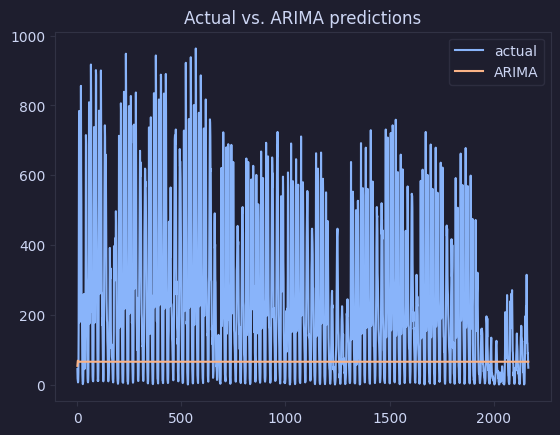

In [ ]:
# plot ARIMA predictions
plt.plot(valid["cnt"].values, label="actual")
plt.plot(classical_forec_models_pred_df["ARIMA predictions"].values, label="ARIMA")
plt.legend()
plt.title("Actual vs. ARIMA predictions")
plt.show()

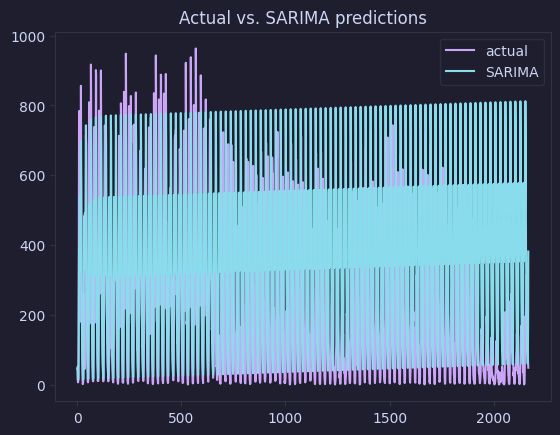

In [ ]:
# plot SARIMA predictions
plt.plot(valid["cnt"].values, label="actual", color=catppuccin.PALETTE.mocha.colors.mauve.hex)
plt.plot(classical_forec_models_pred_df["SARIMA predictions"].values, label="SARIMA", color=catppuccin.PALETTE.mocha.colors.sky.hex)
plt.legend()
plt.title("Actual vs. SARIMA predictions")
plt.show()

## 16. XG Boost Optuna Model Metrics

In [51]:
optuna_opt_xgb_metrics_df.head()

,R² score,MAE,RMSE
Optuna-optimized XG Boost,0.947699,29.448454,46.101501


Optuna-optimized XG Boost model didn't massively outperform GridSearch and that's expected as Optuna explores the space more intelligently and scales better when we have many hyperparameters. If I used more hyperparameters (I used only `n_estimators`, `learning_rate`, `max_depth`, `subsample` and `colsample_bytree`), I'd expect Optuna to outperform GridSearch.

## 17. Optuna Trials

In [52]:
optuna_trials_df.head()

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_learning_rate,params_max_depth,params_n_estimators,params_subsample,state
0,0,0.892642,2026-07-18 13:17:01.747737,2026-07-18 13:17:04.009184,0 days 00:00:02.261447,0.578009,0.190636,8,250,0.799329,COMPLETE
1,1,0.878480,2026-07-18 13:17:04.010704,2026-07-18 13:17:05.886468,0 days 00:00:01.875764,0.854036,0.021036,9,162,0.800558,COMPLETE
2,2,0.878949,2026-07-18 13:17:05.887709,2026-07-18 13:17:06.988787,0 days 00:00:01.101078,0.590912,0.194283,9,108,0.606170,COMPLETE
3,3,0.899756,2026-07-18 13:17:06.990028,2026-07-18 13:17:08.089959,0 days 00:00:01.099931,0.645615,0.067806,7,173,0.715973,COMPLETE
4,4,0.914237,2026-07-18 13:17:08.091247,2026-07-18 13:17:09.412898,0 days 00:00:01.321651,0.728035,0.036504,5,345,0.683181,COMPLETE


In [53]:
# show the best trial
best_trial = optuna_trials_df.sort_values(by="value", ascending=False).head()

best_trial

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_learning_rate,params_max_depth,params_n_estimators,params_subsample,state
33,33,0.918047,2026-07-18 13:17:48.316089,2026-07-18 13:17:49.184243,0 days 00:00:00.868154,0.618166,0.114345,4,268,0.840879,COMPLETE
31,31,0.917954,2026-07-18 13:17:46.649229,2026-07-18 13:17:47.518271,0 days 00:00:00.869042,0.677400,0.101668,3,307,0.829395,COMPLETE
48,48,0.917199,2026-07-18 13:18:03.352885,2026-07-18 13:18:04.337011,0 days 00:00:00.984126,0.741657,0.106499,3,354,0.856337,COMPLETE
44,44,0.917002,2026-07-18 13:17:59.139415,2026-07-18 13:18:00.158422,0 days 00:00:01.019007,0.750168,0.108270,3,340,0.887547,COMPLETE
32,32,0.916812,2026-07-18 13:17:47.519536,2026-07-18 13:17:48.314693,0 days 00:00:00.795157,0.658418,0.102448,3,291,0.829772,COMPLETE


Trial 17 achieved the highest CV R² score (0.918), using a learning rate of 0.114, maximum depth of 4, 268 estimators, subsample of 0.84 and colsample_bytree of 0.62.

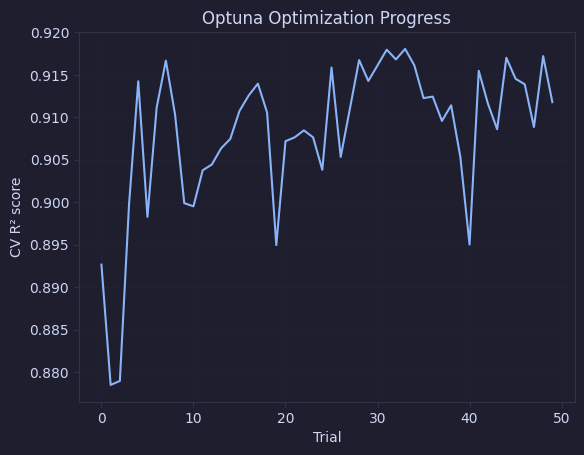

In [ ]:
# optimization progress
plt.plot(optuna_trials_df["number"], optuna_trials_df["value"])
plt.xlabel("Trial")
plt.ylabel("CV R² score")
plt.title("Optuna Optimization Progress")
plt.grid(alpha=0.2)
plt.show()

- The chart starts with massive volatility which is expected as it's the typical behaviour of Optuna's sampler. It's randomly sampling the hyperparameter space to establish a baseline.

- After trial 10, the curve shows a steady upward trend with a few sharp drawdowns (like at trial 19 roughly). This means that the sampler is learning and has identified promising areas in the hyperparameter space.

- From trials 36 to 50, the score fluctuates most of the times, which means that the optimization has largely converged. Optuna has found the optimal neighborhood for the hyperparameters and the remaining variance is likely just noise.

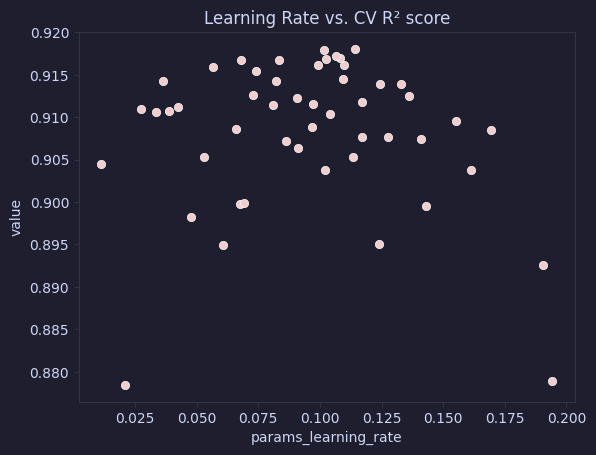

In [ ]:
# parameter vs. score
sns.scatterplot(data=optuna_trials_df, x="params_learning_rate", y="value", color=catppuccin.PALETTE.mocha.colors.flamingo.hex)
plt.title("Learning Rate vs. CV R² score")
plt.show()

We can see that higher learning rates don't perform as well as moderate learning rates.

- `learning_rate` between 0.10 and 0.12 can be considered the optimal zone, which has the highest CV R² scores.

- the zone with a `learning_rate` between 0.075 and 0.125 is the region that yields the highest average performance, suggesting that this region produced the best trade-off.

- if we move below 0.05, the scores start dropping off, including a massive failure at around 0.878. When the `learning_rate` is too small, the model updates its weights too slowly.

- as the `learning_rate` pushes past 0.13 toward 0.20, the dots start trending down. When the `learning_rate` is too large, the model takes steps that are too aggressive.